In [16]:
import pandas as pd
import numpy as np

In [17]:

from sklearn.preprocessing import LabelEncoder

try:
    df = pd.read_excel("/root/heart_disease_uci.csv")
    print(" Read as Excel file")
except Exception:
    df = pd.read_csv("/root/heart_disease_uci.csv", encoding='latin1', sep=None, engine='python', on_bad_lines='skip')
    print(" Read as CSV file")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nColumns:", df.columns.tolist())

cols_to_drop = [col for col in ["id", "dataset"] if col in df.columns]
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)

bool_cols    = ["fbs", "exang"]
str_cols     = ["sex", "cp", "restecg", "slope", "thal"]
num_cols     = ["trestbps", "chol", "thalch", "oldpeak", "ca"]

bool_cols = [col for col in bool_cols if col in df.columns]
str_cols  = [col for col in str_cols  if col in df.columns]
num_cols  = [col for col in num_cols  if col in df.columns]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in bool_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in str_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after imputation:\n", df.isnull().sum())

df["fbs"]   = df["fbs"].map({True: "yes", False: "no"})
df["exang"] = df["exang"].map({True: "yes", False: "no"})

for col in str_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nUnique values after standardisation:")
for col in str_cols + bool_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

categorical_cols = str_cols + bool_cols
label_encoders   = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("\nLabel encoding mappings:")
for col, mapping in label_encoders.items():
    print(f"  {col}: {mapping}")

df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num"], inplace=True)

print("\nTarget distribution:\n", df["target"].value_counts())

print("\n--- Final Checks ---")
print("Shape              :", df.shape)
print("All numeric dtypes :", all(df.dtypes != "object"))
print("Any nulls left     :", df.isnull().values.any())
print("Duplicate rows     :", df.duplicated().sum())
print("\nData types:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))

feature_guide = {
    "age"      : "Patient age in years",
    "sex"      : "Biological sex — encoded: female=0, male=1",
    "cp"       : "Chest pain type — asymptomatic / atypical angina / non-anginal / typical angina",
    "trestbps" : "Resting blood pressure (mm Hg) on admission",
    "chol"     : "Serum cholesterol (mg/dl)",
    "fbs"      : "Fasting blood sugar > 120 mg/dl — no=0, yes=1",
    "restecg"  : "Resting ECG results — lv hypertrophy / normal / st-t abnormality",
    "thalch"   : "Maximum heart rate achieved during exercise",
    "exang"    : "Exercise-induced angina — no=0, yes=1",
    "oldpeak"  : "ST depression induced by exercise relative to rest",
    "slope"    : "Slope of the peak exercise ST segment — downsloping / flat / upsloping",
    "ca"       : "Number of major vessels (0-3) coloured by fluoroscopy",
    "thal"     : "Thalassemia type — fixed defect / normal / reversable defect",
    "target"   : "Heart disease presence — 0 = no disease, 1 = disease"
}
print("\n--- Feature Reference Guide ---")
for feat, desc in feature_guide.items():
    print(f"  {feat:<12} : {desc}")

df.to_csv("heart_disease_cleaned.csv", index=False)
print("\n Cleaned dataset saved to heart_disease_cleaned.csv")

 Read as CSV file
Shape: (920, 16)

Data types:
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Missing values after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope    

/tmp/ipykernel_5790/1096741033.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_5790/1096741033.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [18]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv("/content/drive/MyDrive/heart_disease_cleaned.csv", index=False)
print(" Saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Saved to Google Drive


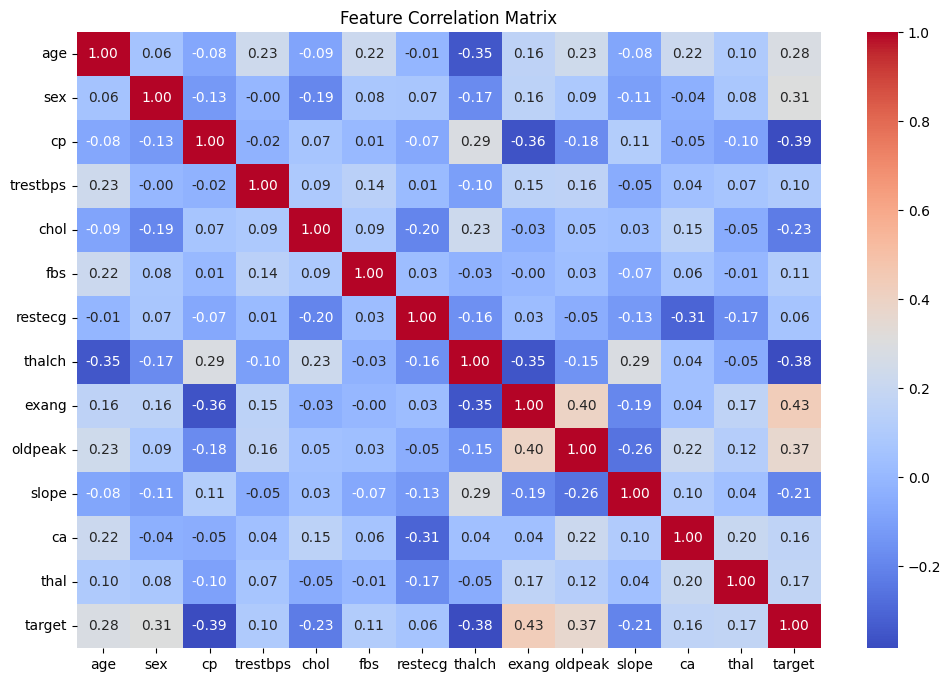


Highly correlated features to remove: []

--- Data Split Summary ---
Total features: 13
Training set (80%): 736 samples
Testing set (20%): 184 samples


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

high_corr_threshold = 0.85
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > high_corr_threshold)]

print(f"\nHighly correlated features to remove: {to_drop}")

df_full = df.copy()

df_reduced = df.drop(columns=to_drop)

X = df_full.drop(columns=['target'])
y = df_full['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n--- Data Split Summary ---")
print(f"Total features: {X.shape[1]}")
print(f"Training set (80%): {X_train.shape[0]} samples")
print(f"Testing set (20%): {X_test.shape[0]} samples")